# Detect the overlap in single-channel images

In [13]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

import tifffile as tiff

from scipy.ndimage import  label, center_of_mass, binary_dilation
from skimage.morphology import dilation, disk
from skimage.measure import regionprops


def find_repo_root(start: Path, path_entries: list[str]) -> Path:
    checked = set()
    search_roots = [start.resolve()]

    for entry in path_entries:
        if not entry:
            continue
        try:
            search_roots.append(Path(entry).resolve())
        except OSError:
            continue

    for root in search_roots:
        for candidate in [root, *root.parents]:
            candidate_str = str(candidate)
            if candidate_str in checked:
                continue
            checked.add(candidate_str)
            if (candidate / "src" / "cnt_project").exists() and (candidate / "notebooks").exists():
                return candidate

    raise RuntimeError(
        f"Could not infer repository root from cwd={start} or the current sys.path entries."
    )


REPO_ROOT = find_repo_root(Path.cwd(), sys.path)
SRC_ROOT = REPO_ROOT / "src"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from cnt_project.io.paths import ProjectPaths

PATHS = ProjectPaths.from_here(SRC_ROOT / "cnt_project" / "io" / "paths.py")
PATHS.ensure_outputs()

print("Project root:", PATHS.project_root)
print("Data root:", PATHS.data_root)

Project root: C:\Users\abd93000\PycharmProjects\cnt_project_v2
Data root: C:\Users\abd93000\PycharmProjects\cnt_project_v2\data


In [14]:
def calculate_iou(mask1, mask2):
    """
    Calculate the Intersection over Union (IoU) for two binary masks.
    
    Args:
        mask1 (ndarray): Binary mask 1
        mask2 (ndarray): Binary mask 2
    
    Returns:
        float: IoU score between mask1 and mask2
    """
    intersection = np.sum(mask1 & mask2)
    union = np.sum(mask1 | mask2)
    if union == 0:  # Avoid division by zero
        return 0.0
    return intersection / union

def find_potential_overlap_regions(label_map, threshold=0.0):
    """
    Identifies potential overlap regions by dilating each object by one pixel,
    and computing the IoU with all other objects.

    Args:
        label_map (ndarray): 2D array with integer labels, shape [H, W]
        threshold (float): IoU threshold to consider as an "overlap"
    
    Returns:
        overlap_mask (ndarray): binary mask, 1 where potential overlaps occur
        overlap_regions (list): list of dicts with keys:
            - 'label_id': tuple of adjacent or overlapping object IDs
            - 'mask': binary mask of the overlap region (if any)
    """
    unique_ids = np.unique(label_map)
    unique_ids = unique_ids[unique_ids != 0]  # Skip background
    
    overlap_mask = np.zeros_like(label_map, dtype=np.uint8)
    overlap_regions = []

    for id1 in unique_ids:
        # Dilate the current object's mask by 1 pixel
        mask1 = (label_map == id1).astype(np.uint8)
        dilated_mask1 = dilation(mask1, np.ones((3, 3), dtype=np.uint8))  # 3x3 structuring element
        for id2 in unique_ids:
            if id1 == id2:  # Skip self-comparison
                continue
            
            # Get the mask of the other object
            mask2 = (label_map == id2).astype(np.uint8)

            # Calculate the IoU between the dilated object and the other object
            iou = calculate_iou(dilated_mask1, mask2)

            # If IoU exceeds threshold, this is a potential overlap
            if iou > threshold:
                overlap_mask = np.maximum(overlap_mask, dilated_mask1 | mask2)
                overlap_regions.append({
                    'objects': (id1, id2),
                    'label_id': id1,
                    'mask': (mask1 | mask2).astype(np.uint8),
                    'dilated_mask': dilated_mask1,
                    'mask1': mask1,
                    'mask2': mask2

                })

    return overlap_mask, overlap_regions



In [15]:
input_folder = PATHS.data_root / "annotations_filtered_artifacts" / "masks"
filename = os.listdir(input_folder)[0]
filepath = input_folder / filename
label_map = tiff.imread(filepath)

results = []
overlap_mask, overlap_regions = find_potential_overlap_regions(label_map)
if overlap_regions:
    results.append({
        'filename': filename,
        'overlap_mask': overlap_mask,
        'overlap_regions': overlap_regions
    })
print(results)

[{'filename': '1293-22_3_-2_20230306230321.tif', 'overlap_mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'overlap_regions': [{'objects': (1, 3), 'label_id': 1, 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'dilated_mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'mask1': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, .

overlap_regions

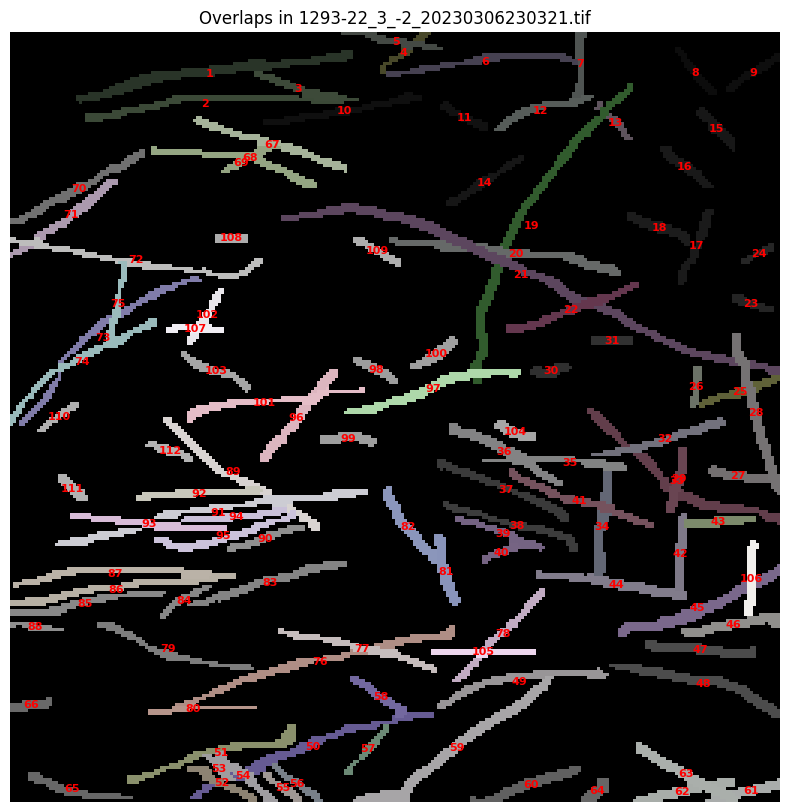

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from scipy.ndimage import center_of_mass



def random_label_cmap(n=2**16, h = (0,1), l = (.4,1), s =(.2,.8)):
    import matplotlib
    import colorsys
    # cols = np.random.rand(n,3)
    # cols = np.random.uniform(0.1,1.0,(n,3))
    h,l,s = np.random.uniform(*h,n), np.random.uniform(*l,n), np.random.uniform(*s,n)
    cols = np.stack([colorsys.hls_to_rgb(_h,_l,_s) for _h,_l,_s in zip(h,l,s)],axis=0)
    cols[0] = 0
    return matplotlib.colors.ListedColormap(cols)

lbl_cmap = random_label_cmap()
for result in results:
    filename = result['filename']
    overlap_mask = result['overlap_mask']
    overlap_regions = result['overlap_regions']

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(label_map, cmap='gray')  # Show all masks in gray
    ax.set_title(f"Overlaps in {filename}")

    # Create labeled overlap image
    overlap_display = np.zeros_like(label_map, dtype=np.uint16)
    for idx, region in enumerate(overlap_regions, start=1):
        region_mask = region['mask'].astype(bool)
        overlap_display[region_mask] = idx

    # Show overlap in color
    ax.imshow(overlap_display, cmap=lbl_cmap, alpha=0.3)

    # Label each object with its ID
    object_ids = np.unique(label_map)
    object_ids = object_ids[object_ids != 0]  # skip background

    for obj_id in object_ids:
        mask = (label_map == obj_id)
        if np.any(mask):
            cy, cx = center_of_mass(mask)
            ax.text(cx, cy, str(obj_id), color='red', fontsize=8, ha='center', va='center', weight='bold')

    ax.axis('off')
    plt.show()


In [12]:
results = []

for filename in os.listdir(input_folder):
    if filename.lower().endswith(".tif"):
        filepath = os.path.join(input_folder, filename)
        label_map = tiff.imread(filepath)

        overlap_mask, overlap_regions = find_potential_overlap_regions(label_map)

        if overlap_regions:
            results.append({
                'filename': filename,
                'overlap_mask': overlap_mask,
                'overlap_regions': overlap_regions
            })


In [16]:
def find_interruption_regions(label_map, dilation_radius=1):
    """
    Find regions where an object with a single ID is interrupted (split) by other objects.

    Args:
        label_map (ndarray): 2D label map of objects.
        dilation_radius (int): How far to dilate fragments to find intersections.

    Returns:
        List of dicts with interruption masks and associated object.
    """
    interruptions = []

    object_ids = np.unique(label_map)
    object_ids = object_ids[object_ids != 0]

    structure = np.ones((3, 3), dtype=np.uint8)  # for dilation

    for obj_id in object_ids:
        obj_mask = (label_map == obj_id)
        labeled_parts, num_parts = label(obj_mask)

        if num_parts > 1:
            # Dilate each part slightly
            masks = [(labeled_parts == i + 1) for i in range(num_parts)]
            dilated = [binary_dilation(m, structure=structure, iterations=dilation_radius) for m in masks]

            # Find intersections between dilated components
            for i in range(num_parts):
                for j in range(i + 1, num_parts):
                    intersection = dilated[i] & dilated[j]
                    if np.any(intersection):
                        interruptions.append({
                            'object': obj_id,
                            'mask': intersection,
                        })

    return interruptions


In [17]:

def plot_masks_with_labels(label_map, masks, ax=None):
    """
    Plots the label_map and overlays each mask label on the provided axis.

    Args:
        label_map (ndarray): 2D array of the label map.
        masks (dict): Dictionary of masks for each object.
        ax (matplotlib axis): Optional axis to plot on.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(label_map, cmap='gray')

    for label_id, mask in masks.items():
        regions = regionprops(mask.astype(np.uint8))
        for region_info in regions:
            y, x = region_info.centroid
            ax.text(x, y, str(label_id), color='red', fontsize=8, ha='center', va='center')

    ax.axis('off')

    

def plot_overlap(label_map, filename, overlap_regions, display_text=False, alpha=0.3, ax=None, cmap=lbl_cmap):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(label_map, cmap='gray')
    ax.set_title(f"Overlaps in {filename}")

    overlap_display = np.zeros_like(label_map, dtype=np.uint16)
    for idx, region in enumerate(overlap_regions, start=1):
        region_mask = region['mask'].astype(bool)
        overlap_display[region_mask] = idx
    lbl_cmap = random_label_cmap()
    ax.imshow(overlap_display, cmap=lbl_cmap, alpha=alpha)

    if display_text==True:
        object_ids = np.unique(label_map)
        object_ids = object_ids[object_ids != 0]
        
        for obj_id in object_ids:
            mask = (label_map == obj_id)
            if np.any(mask):
                cy, cx = center_of_mass(mask)
                ax.text(cx, cy, str(obj_id), color='red', fontsize=3, ha='center', va='center', weight='bold')

    ax.axis('off')



In [18]:
def complete_overlap_region(region_mask, max_distance=20):
    labeled_mask, num_labels = label(region_mask)
    if num_labels <= 1:
        return np.zeros_like(region_mask, dtype=bool)

    centers = center_of_mass(region_mask, labeled_mask, range(1, num_labels + 1))
    centers = np.array(centers).astype(int)

    filled_mask = np.zeros_like(region_mask, dtype=bool)

    for i in range(len(centers)):
        for j in range(i + 1, len(centers)):
            y1, x1 = centers[i]
            y2, x2 = centers[j]
            distance = np.hypot(y2 - y1, x2 - x1)
            if distance <= max_distance:
                # Dilate components until they touch
                comp_i = (labeled_mask == i + 1)
                comp_j = (labeled_mask == j + 1)

                dil_i = binary_dilation(comp_i, disk(max_distance))
                dil_j = binary_dilation(comp_j, disk(max_distance))

                if np.any(np.logical_and(dil_i, dil_j)):
                    connection = np.logical_and(dil_i, dil_j)
                    filled_mask = np.logical_or(filled_mask, connection)
                    break

    return np.logical_and(filled_mask, ~region_mask)


def fill_disconnected_objects(label_map, overlap_regions, max_distance=20):
    filled_masks = []

    for region in overlap_regions:
        obj1, obj2 = region['objects']
        mask1 = (label_map == obj1)
        mask2 = (label_map == obj2)

        n_labels1 = label(mask1)[1]
        n_labels2 = label(mask2)[1]

        # Skip if both are single components
        if n_labels1 <= 1 and n_labels2 <= 1:
            continue

        # Determine which object needs to be filled
        if n_labels1 > 1:
            fill_obj = obj1
            fill_mask = mask1
        elif n_labels2 > 1:
            fill_obj = obj2
            fill_mask = mask2
        else:
            continue

        # Fill the mask between disconnected components
        filled = complete_overlap_region(fill_mask, max_distance=max_distance)

        if np.any(filled):
            filled_masks.append({'label_id': (fill_obj,), 'mask': filled.astype(np.uint8)})

    return filled_masks


In [19]:
import cv2
import numpy as np

def merge_contours(contours, region_mask, distance_threshold=50):
    """ Merges contours that are inside or overlap with the region mask and within a given distance threshold. """
    merged_contour = []

    for contour in contours:
        # Check if the contour has any intersection with the region mask
        mask = np.zeros_like(region_mask, dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, color=255, thickness=cv2.FILLED)

        # If the contour is outside the region mask, skip it
        if np.any(mask & region_mask):
            if not merged_contour:
                merged_contour.append(contour)
            else:
                # Find the centroid of the current contour and the merged contour
                M1 = cv2.moments(merged_contour[-1])
                M2 = cv2.moments(contour)
                if M1['m00'] != 0:
                    c1 = (int(M1['m10'] / M1['m00']), int(M1['m01'] / M1['m00']))
                else:
                    c1 = (0, 0)
                if M2['m00'] != 0:
                    c2 = (int(M2['m10'] / M2['m00']), int(M2['m01'] / M2['m00']))
                else:
                    c2 = (0, 0)

                # Calculate distance between centroids
                distance = np.linalg.norm(np.array(c1) - np.array(c2))

                if distance < distance_threshold:
                    # If distance is smaller than threshold, merge contours
                    merged_contour.append(contour)
                else:
                    # Otherwise, just add the current contour
                    merged_contour.append(contour)

    # Now merge all the contours into one
    if merged_contour:
        merged_contour = np.vstack(merged_contour)
    return merged_contour

def fill_cut_objects_via_contours(label_map, overlap_regions):
    filled_masks = []

    for region in overlap_regions:
        obj1, obj2 = region['objects']
        region_mask = region['mask'].astype(np.uint8)  # Union of obj1 and obj2

        # Rebuild each mask inside the overlap region
        mask1 = (label_map == obj1).astype(np.uint8)
        mask2 = (label_map == obj2).astype(np.uint8)

        for obj, mask in [(obj1, mask1), (obj2, mask2)]:
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if len(contours) > 1:
                # Merge contours only if they are within the region mask
                merged_contour = merge_contours(contours, region_mask, distance_threshold=50)

                if len(merged_contour) > 0:   # If there is any merged contour
                    # Create a filled mask for the merged contours
                    filled = np.zeros_like(mask)
                    cv2.drawContours(filled, [merged_contour], -1, color=1, thickness=cv2.FILLED)

                    new_pixels = filled & (~mask)
                    overlapping_area = filled & mask

                    if np.any(new_pixels):
                        filled_masks.append({
                            'object': obj,
                            'mask': new_pixels.astype(np.uint8),
                            'overlap': overlapping_area
                        })

    return filled_masks



In [20]:
filled_masks = fill_cut_objects_via_contours(label_map, overlap_regions)

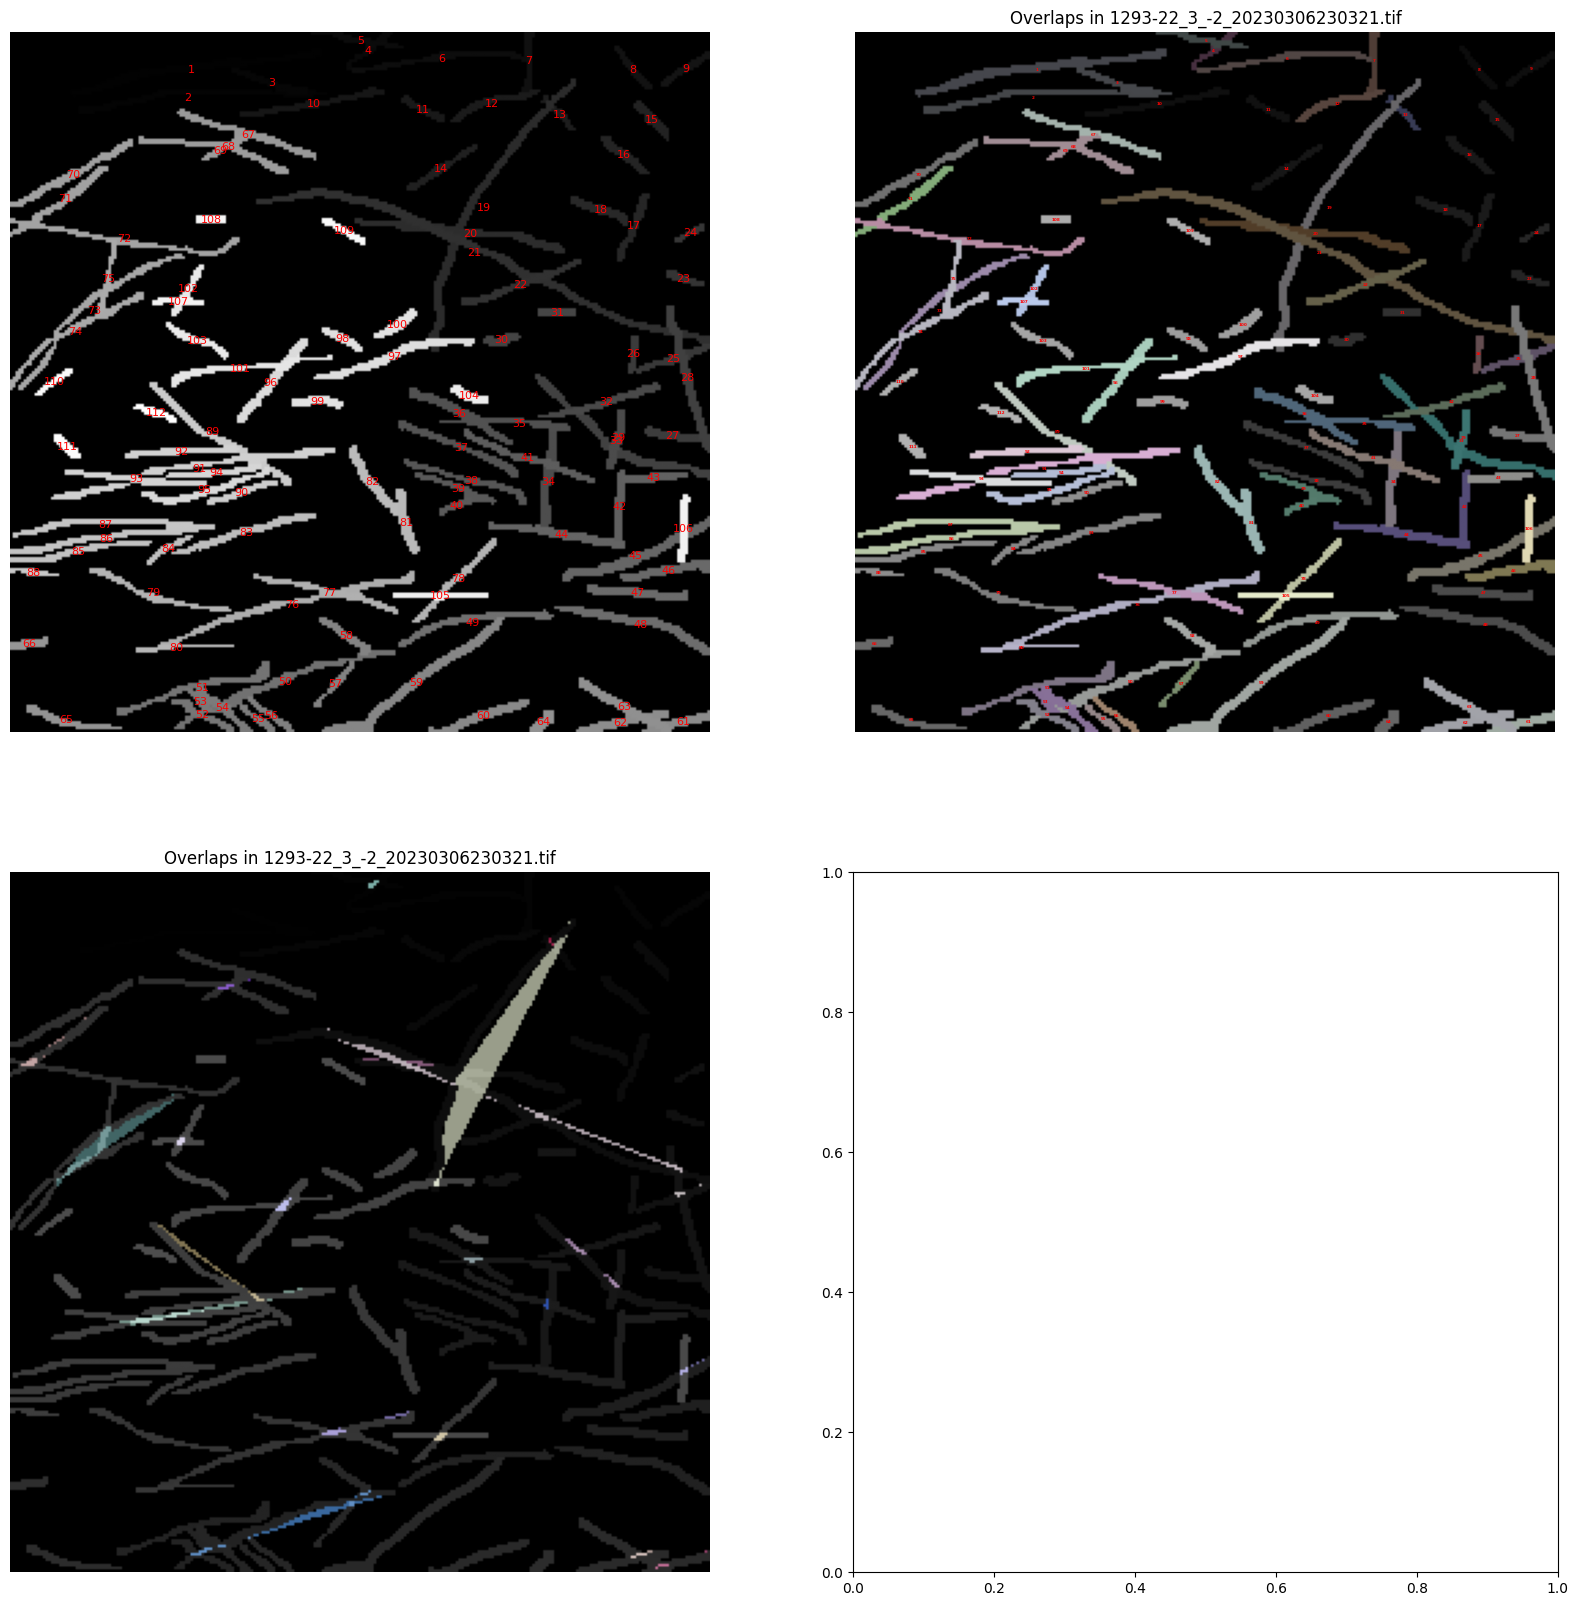

In [23]:
fig, ax = plt.subplots(2,2, figsize=(20, 20))

unique_ids = np.unique(label_map)
unique_ids = unique_ids[unique_ids != 0]  # skip background
masks = {uid: (label_map == uid).astype(np.uint8) for uid in unique_ids}
interruption_regions = find_interruption_regions(label_map, dilation_radius=2)
#filled_masks = fill_disconnected_objects(label_map, overlap_regions, max_distance=10)
#filled_masks = fill_cut_objects(label_map, overlap_regions)

plot_masks_with_labels(label_map, masks, ax=ax[0][0])
plot_overlap(label_map, filename, overlap_regions, display_text=True, alpha=0.3, ax=ax[0][1])
plot_overlap(label_map, filename, interruption_regions, display_text=False, alpha=0.7, ax=ax[1][0])
plot_overlap(label_map, filename, filled_masks, display_text=False, alpha=0.7, ax=ax[1][0])


plt.show()